# Assignment

**Create Panorama image**

**Instruction : This section you need to create 1 panorama from 3 pier images.**

In [ ]:
#1st image : peir_1.jpg
!gdown "1Gstc-9xF_3s7jB6uwB4tHzsUVY2usv0k"

#2st image : peir_2.jpg
!gdown "1mPucyctY8YJOQlxzp3yZwM1NhMC--fPN"

#3st image : peir_3.jpg
!gdown "1qLRpmiTVx96DwAjGNP0580cb8yJ0GA44"

Downloading...
From: https://drive.google.com/uc?id=1Gstc-9xF_3s7jB6uwB4tHzsUVY2usv0k
To: /content/pier_1.JPG
100% 122k/122k [00:00<00:00, 15.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mPucyctY8YJOQlxzp3yZwM1NhMC--fPN
To: /content/pier_2.JPG
100% 116k/116k [00:00<00:00, 74.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qLRpmiTVx96DwAjGNP0580cb8yJ0GA44
To: /content/pier_3.JPG
100% 120k/120k [00:00<00:00, 70.3MB/s]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

## Smoothing

In [ ]:
def create_mask(query_image, train_image, version):
        smoothing_window_percent = 0.10 # consider increasing or decreasing[0.00, 1.00]
        width_query_photo = query_image.shape[1]
        width_train_photo = train_image.shape[1]
        lowest_width = min(width_query_photo, width_train_photo)
        smoothing_window_size = max(100, min(smoothing_window_percent * lowest_width, 1000))

        height_query_photo = query_image.shape[0]
        height_panorama = height_query_photo
        width_panorama = width_query_photo + width_train_photo

        offset = int(smoothing_window_size / 2)
        barrier = query_image.shape[1] - int(smoothing_window_size / 2)
        mask = np.zeros((height_panorama, width_panorama))
        if version == "left_image":
            mask[:, barrier - offset : barrier + offset] = np.tile(
                np.linspace(1, 0, 2 * offset).T, (height_panorama, 1)
            )
            mask[:, : barrier - offset] = 1
        else:
            mask[:, barrier - offset : barrier + offset] = np.tile(
                np.linspace(0, 1, 2 * offset).T, (height_panorama, 1)
            )
            mask[:, barrier + offset :] = 1
        return cv2.merge([mask, mask, mask])

In [ ]:
def blending_smoothing(query_image, train_image, homography_matrix):
        height_img1 = query_image.shape[0]
        width_img1 = query_image.shape[1]
        width_img2 = train_image.shape[1]
        height_panorama = height_img1
        width_panorama = width_img1 + width_img2

        panorama1 = np.zeros((height_panorama, width_panorama, 3))
        mask1 = create_mask(query_image, train_image, version="left_image")
        panorama1[0 : query_image.shape[0], 0 : query_image.shape[1], :] = query_image
        panorama1 *= mask1
        mask2 = create_mask(query_image, train_image, version="right_image")
        panorama2 = (
            cv2.warpPerspective(
                train_image, homography_matrix, (width_panorama, height_panorama)
            )
            * mask2
        )
        result = panorama1 + panorama2

        # remove extra blackspace
        rows, cols = np.where(result[:, :, 0] != 0)
        min_row, max_row = min(rows), max(rows) + 1
        min_col, max_col = min(cols), max(cols) + 1

        final_result = result[min_row:max_row, min_col:max_col, :]

        return final_result

## Display

In [ ]:
def display_images(images):

    #Check that image is list type or not.
    if not isinstance(images, list):
        #If not list type
        figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(images, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
        plt.axis('off')
        return

    n = len(images)
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    print("n = ",n)
    print("cols = ",cols)
    print("rows = ",rows)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    print("axes before: ",len(axes))
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    print("axes after: ",len(axes))

    for i in range(n):
        axes[i].imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
        axes[i].axis('off') #hide axis


    # Hide any unused subplots
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
pier1 = cv2.imread('pier_1.JPG')
pier2 = cv2.imread('pier_2.JPG')
pier3 = cv2.imread('pier_3.JPG')

n =  3
cols =  2
rows =  2
axes before:  2
axes after:  4


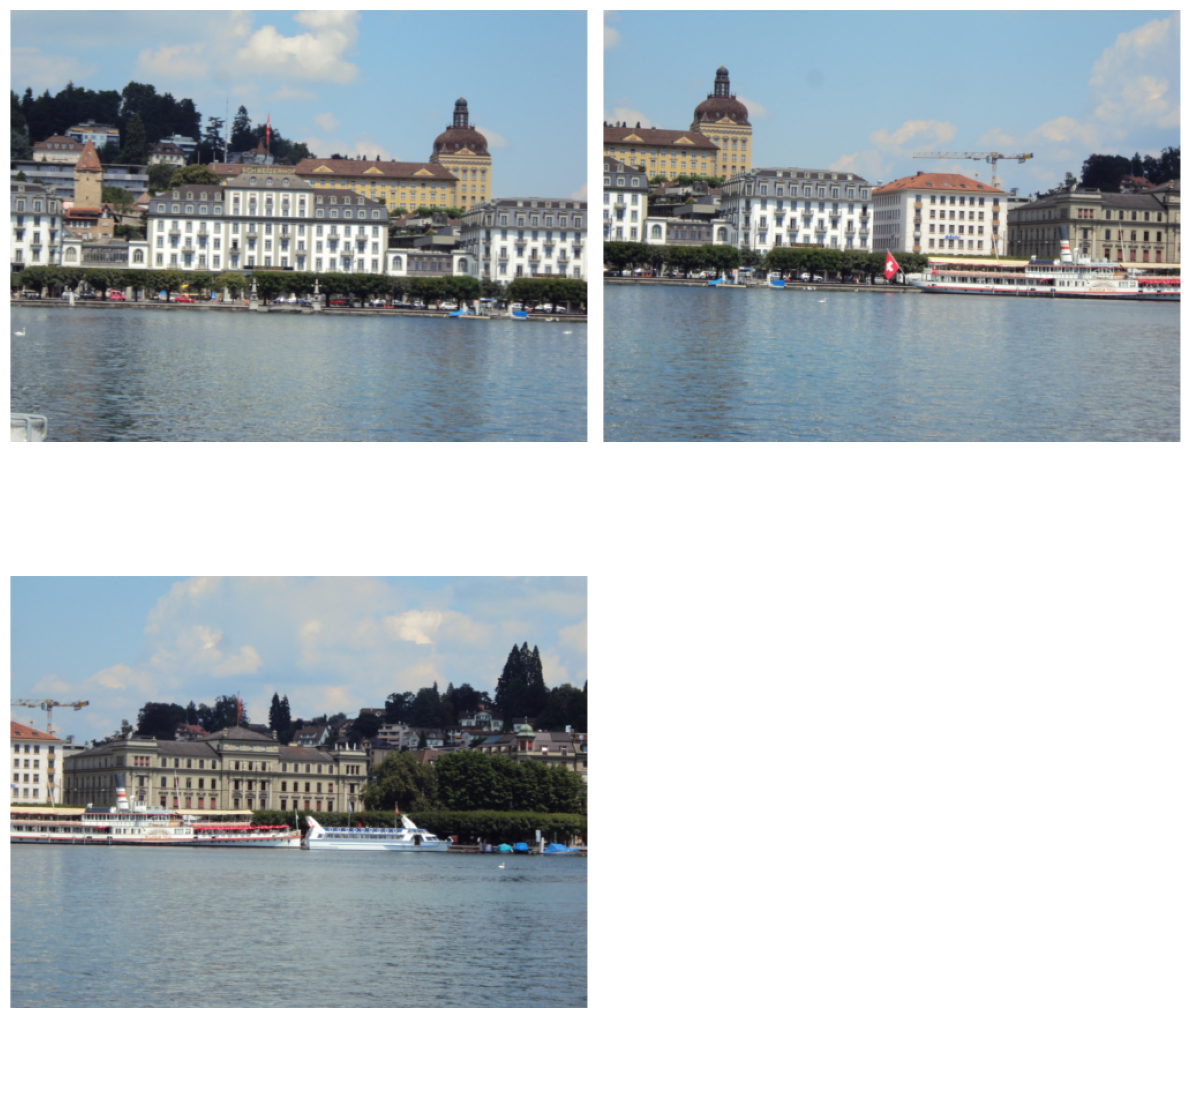

In [ ]:
display_images([pier1,pier2,pier3])

## Feature detection and matching

In [ ]:
# Create SIFT object
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints1, descriptors1 = sift.detectAndCompute(pier1, None)
keypoints2, descriptors2 = sift.detectAndCompute(pier2, None)

keypoints_drawn_p1 = cv2.drawKeypoints(pier1, keypoints1, None, color=(0, 0, 255))
keypoints_drawn_p2 = cv2.drawKeypoints(pier2, keypoints2, None, color=(0, 0, 255))

## Import Matcher

In [ ]:
bf = cv2.BFMatcher()

## Matching Pier1 and Pier2

In [ ]:
matches_1_2 = bf.knnMatch(descriptors1, descriptors2, k=2)

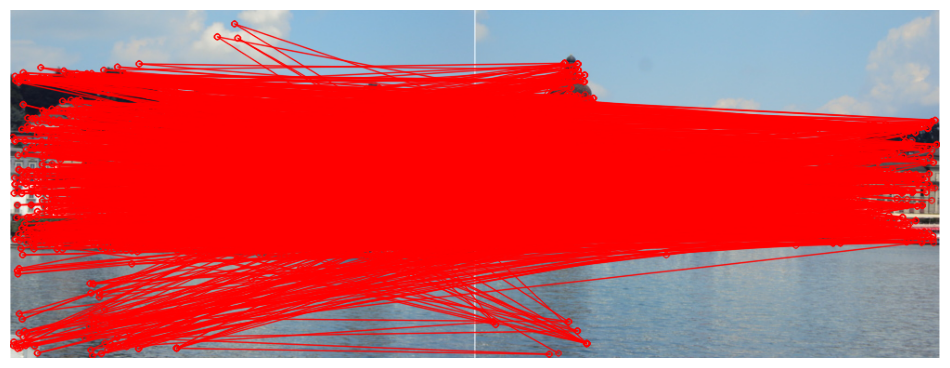

In [ ]:
# Draw only matches for single point won't show.
img_matches_1_2 = cv2.drawMatchesKnn(pier1, keypoints1, pier2, keypoints2, matches_1_2, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches
display_images(img_matches_1_2)

In [ ]:
good_matches_1_2 = []
for m, n in matches_1_2:
  if m.distance < 0.75 * n.distance:
    good_matches_1_2.append([m])

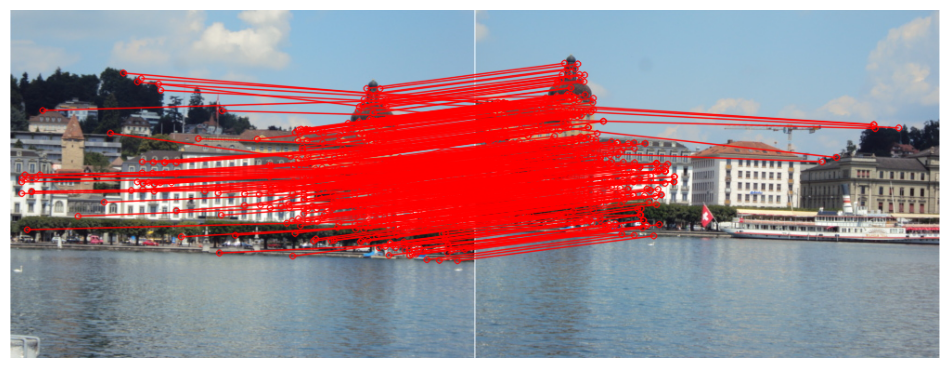

In [ ]:
# Draw matches
img_matches = cv2.drawMatchesKnn(pier1, keypoints1, pier2, keypoints2, good_matches_1_2, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches

display_images(img_matches)

### Ransac Algorithm

In [ ]:
# Extract the matched keypoints
# Each keypoint contains a .pt attribute, which stores the (x, y) coordinates of the keypoint.
src_pts = np.float32([ keypoints1[m[0].queryIdx].pt for m in good_matches_1_2 ]).reshape(-1,1,2)
dst_pts = np.float32([ keypoints2[m[0].trainIdx].pt for m in good_matches_1_2 ]).reshape(-1,1,2)

# Apply RANSAC algorithm to remove outliers
#H = homography matrix (is ​​the relationship of pixel positions between two images.)
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Filter the good matches using the RANSAC mask
good_matches_ransac12 = [good_matches_1_2[i] for i in range(len(good_matches_1_2)) if mask[i]]

In [ ]:
# Draw matches
img_matches_12 = cv2.drawMatchesKnn(pier1, keypoints1, pier2, keypoints2, good_matches_ransac12, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)


In [ ]:
limit = 50
good_matches_ransac_top12 = sorted(good_matches_ransac12, key = lambda x:x[0].distance)[:limit]
# Draw matches
img_matches = cv2.drawMatchesKnn(pier1, keypoints1, pier2, keypoints2, good_matches_ransac_top12, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)


In [ ]:
selected_good_matches = good_matches_ransac_top12
# selected_good_matches=good_matches_ransac
src_pts = np.float32([ keypoints1[m[0].queryIdx].pt for m in selected_good_matches]).reshape(-1,1,2)
dst_pts = np.float32([ keypoints2[m[0].trainIdx].pt for m in selected_good_matches]).reshape(-1,1,2)

H, _ = cv2.findHomography(np.float32(dst_pts), np.float32(src_pts))

In [ ]:
result = blending_smoothing(pier1, pier2, H)

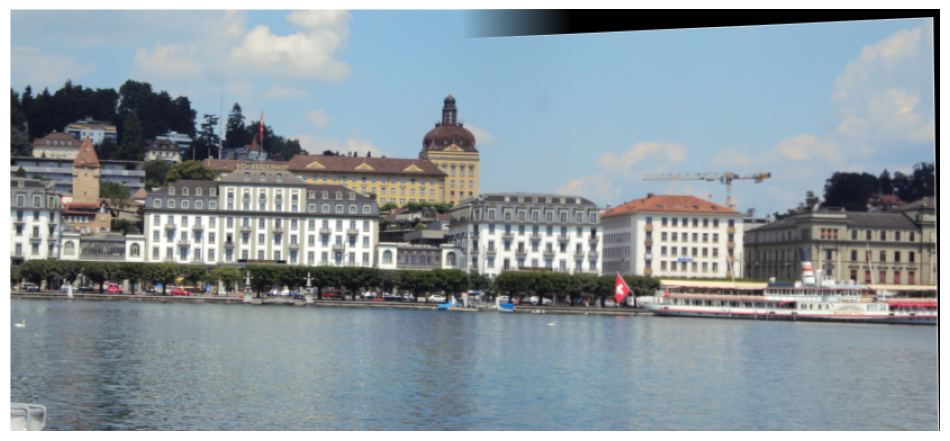

In [ ]:
result2 = np.uint8(result)
display_images(result2)

827
375


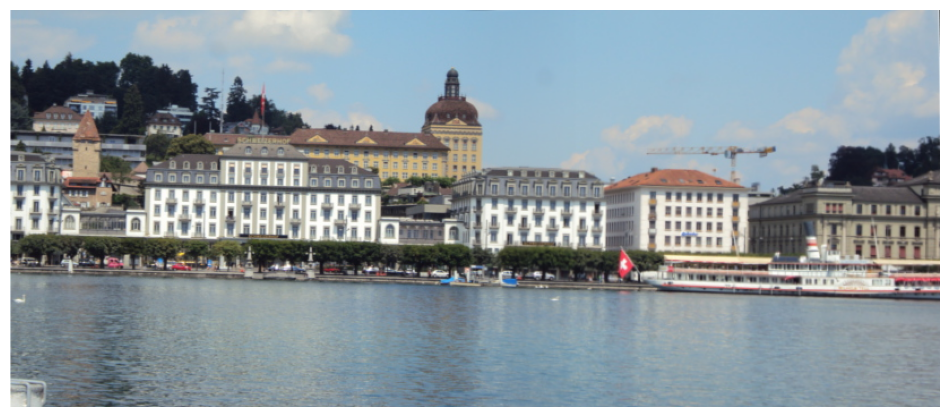

In [ ]:
comb = result2.copy()
print(comb.shape[1])
print(comb.shape[0])

# combine the two images
# comb[0:pier1.shape[0],0:pier1.shape[1]] = pier1
# crop
y_crop = 822 #1920
x_crop = 375
comb_12 = comb[24:x_crop, :y_crop]
display_images(comb_12)

## Matching Pier1,Pier2 and Pier3  

In [ ]:
keypoints1_2, descriptors1_2 = sift.detectAndCompute(comb_12, None)
keypoints3, descriptors3 = sift.detectAndCompute(pier3, None)

# keypoints_drawn_p1_2 = cv2.drawKeypoints(comb_12, keypoints1_2, None, color=(0, 0, 255))
# keypoints_drawn_p3 = cv2.drawKeypoints(pier3, keypoints3, None, color=(0, 0, 255))

In [ ]:
matches_1_2_3 = bf.knnMatch(descriptors1_2, descriptors3, k=2)

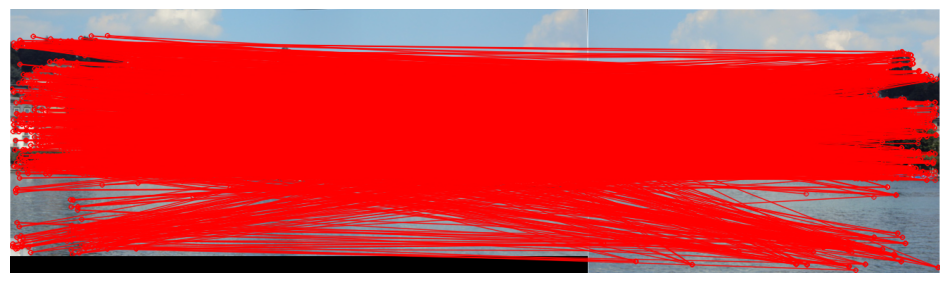

In [ ]:
# Draw only matches for single point won't show.
img_matches_1_2_3 = cv2.drawMatchesKnn(comb_12, keypoints1_2, pier3, keypoints3, matches_1_2_3, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches
display_images(img_matches_1_2_3)

In [ ]:
good_matches_1_2_3 = []
for m, n in matches_1_2_3:
  if m.distance < 0.75 * n.distance:
    good_matches_1_2_3.append([m])


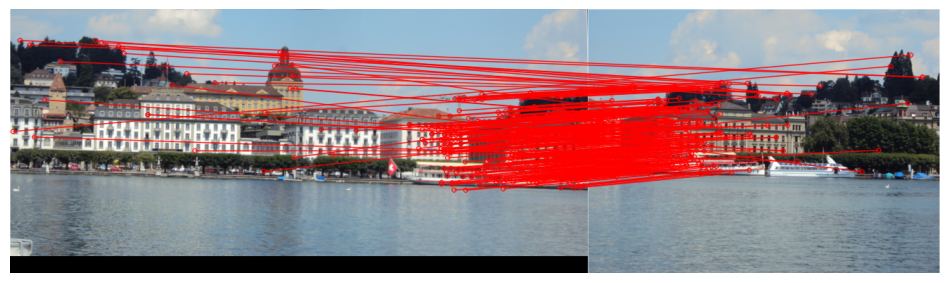

In [ ]:
# Draw matches
img_matches = cv2.drawMatchesKnn(comb_12, keypoints1_2, pier3, keypoints3, good_matches_1_2_3, None, matchColor=(0,0,255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches

display_images(img_matches)

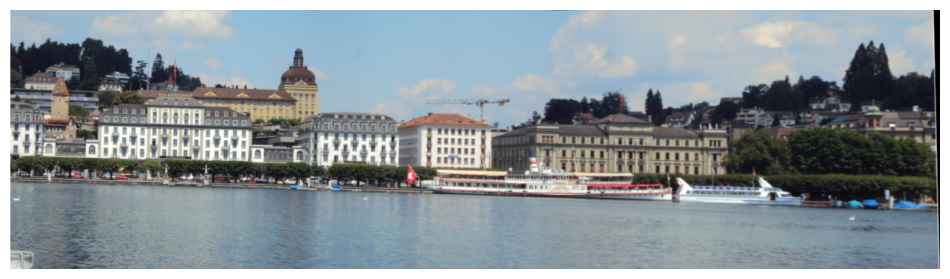

In [ ]:
# Extract the matched keypoints
# Each keypoint contains a .pt attribute, which stores the (x, y) coordinates of the keypoint.
src_pts = np.float32([ keypoints1_2[m[0].queryIdx].pt for m in good_matches_1_2_3 ]).reshape(-1,1,2)
dst_pts = np.float32([ keypoints3[m[0].trainIdx].pt for m in good_matches_1_2_3 ]).reshape(-1,1,2)

# Apply RANSAC algorithm to remove outliers
#H = homography matrix (is ​​the relationship of pixel positions between two images.)
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Filter the good matches using the RANSAC mask
good_matches_ransac1_2_3 = [good_matches_1_2_3[i] for i in range(len(good_matches_1_2_3)) if mask[i]]

limit = 50
good_matches_ransac_top123 = sorted(good_matches_ransac1_2_3, key = lambda x:x[0].distance)[:limit]

selected_good_matches = good_matches_ransac_top123
# selected_good_matches=good_matches_ransac
src_pts = np.float32([ keypoints1_2[m[0].queryIdx].pt for m in selected_good_matches]).reshape(-1,1,2)
dst_pts = np.float32([ keypoints3[m[0].trainIdx].pt for m in selected_good_matches]).reshape(-1,1,2)

H, _ = cv2.findHomography(np.float32(dst_pts), np.float32(src_pts))

result123 = blending_smoothing(comb_12, pier3, H)
result_fin = np.uint8(result123)
display_images(result_fin)
# dim_x = comb_12.shape[1] + pier3.shape[1]
# dim_y = max(comb_12.shape[0], pier3.shape[0])
# dim = (dim_x, dim_y)

# warped123 = cv2.warpPerspective(pier3, H, dim)
# display_images(warped123)

1260
351


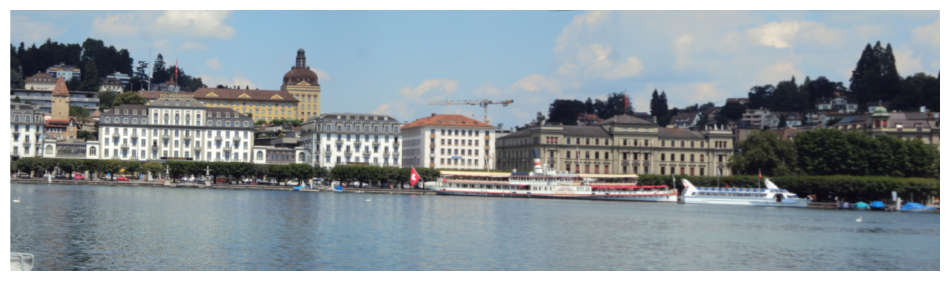

In [ ]:
comb = result_fin.copy()
print(comb.shape[1])
print(comb.shape[0])

# combine the two images
# comb[0:comb_12.shape[0],0:comb_12.shape[1]] = comb_12
# crop
y_crop = 1250 #1920
x_crop = 351
comb_123 = comb[:x_crop, :y_crop]
display_images(comb_123)